<a href="https://colab.research.google.com/github/idoalltime-glitch/data-science-ex1-Ido-Wazana./blob/main/data_science_ex1_Ido_Wazana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## 2. Dataset Selection

* **2.1 Project Overview (What, Why, and What We Learn):** In simple terms, we are analyzing how Israeli electricity consumers are switching from the traditional national monopoly to private electricity suppliers. We want to measure how many switching requests succeed, how many get rejected, and what the main reasons for rejection are. This dataset teaches us whether the electricity market reform is working smoothly in practice or where the main friction points are.

* **2.2 Data Source:** Israel Official Government Data Portal (`data.gov.il`).

* **2.3 Collection Purpose:** Tracking, monitoring, and analyzing consumer requests to switch electricity suppliers to private companies as part of the electricity market reform in Israel.

* **2.4 Collecting Entity:** Noga - Israel Independent System Operator Ltd. (ניהול מערכת החשמל) & The Israeli Electricity Authority.

* **2.5 Domain Knowledge Link:** As an Electrical Engineering background context, the Israeli energy sector is undergoing a major structural reform designed to decentralize the electricity market from a historical monopoly into a competitive ecosystem. Consumers can switch from Israel Electric Corporation (IEC) to private providers. Analyzing this dataset provides operational insights into consumer adoption rates, sector preferences (residential vs. commercial), and procedural friction points (e.g., specific rejection reasons for switching).

* **2.6 Personal Context & Domain Knowledge:** I have a strong personal and professional interest in this topic. For the past 4 years, I have been working in the Israeli power sector as a control room operator at the IPM power station—a private natural gas power plant built by Siemens Energy. Having daily experience on the power generation and grid control side, I am excited to analyze the consumer adoption side. Connecting my practical industry experience with this dataset gives a full picture of how Israel's energy reform operates from generation to the end user.

In [12]:
import os
import time
import pandas as pd

file_name = '/content/drive/MyDrive/03 - studies shit /04 - מדע נתונים /electricity_data.xlsx'

# --- 3.1 File Analysis ---
file_size_bytes = os.path.getsize(file_name)
file_size_kb = file_size_bytes / 1024
file_size_mb = file_size_kb / 1024
file_extension = os.path.splitext(file_name)[1]
mod_time = time.ctime(os.path.getmtime(file_name))

print("==========================================")
print("=== Section 3.1: File Analysis Results ===")
print("==========================================")
print(f"File Format: {file_extension}")
print(f"File Size: {file_size_kb:.2f} KB ({file_size_mb:.2f} MB)")
print(f"Last Modified Time: {mod_time}\n")

# --- 3.2 Data Structure ---
df = pd.read_excel(file_name)

print("=============================================")
print("=== Section 3.2: Data Structure Results ===")
print("=============================================")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print("\nColumn Names & Data Types:")
print(df.dtypes)

print("\n--- Preview of First 5 Rows ---")
display(df.head())

=== Section 3.1: File Analysis Results ===
File Format: .xlsx
File Size: 114.12 KB (0.11 MB)
Last Modified Time: Sun Jul 26 22:33:44 2026

=== Section 3.2: Data Structure Results ===
Number of Rows: 2638
Number of Columns: 8

Column Names & Data Types:
שנה/ חודש                    datetime64[ns]
סוג אסדרה                            object
תחרות באספקה/ אסדרה קיימת            object
ביתי/ לא ביתי                        object
סיבות לססטוס                         object
פירוט סיבת סטטוס                     object
סטטוס                                object
מספר בקשות                            int64
dtype: object

--- Preview of First 5 Rows ---


,שנה/ חודש,סוג אסדרה,תחרות באספקה/ אסדרה קיימת,ביתי/ לא ביתי,סיבות לססטוס,פירוט סיבת סטטוס,סטטוס,מספר בקשות
0,2026-06-01,מספקים עם אמצעי ייצור,אסדרה קיימת,ביתי,אושר לניוד,תהליך הניוד הושלם,הושלם,30353
1,2026-06-01,מספקים עם אמצעי ייצור,אסדרה קיימת,לא ביתי,אושר לניוד,תהליך הניוד הושלם,הושלם,1558
2,2026-06-01,מספקים וירטואליים,תחרות באספקה,ביתי,אושר לניוד,תהליך הניוד הושלם,הושלם,49152
3,2026-06-01,מספקים וירטואליים,תחרות באספקה,לא ביתי,אושר לניוד,תהליך הניוד הושלם,הושלם,1647
4,2026-06-01,מספקים עם אמצעי ייצור,אסדרה קיימת,ביתי,NaN,לא קיים מונה פעיל בחוזה זה,נדחה,1


## 3. Data Meta-Analysis

### 3.1 File Analysis
* **File Size:** 114.12 KB (0.11 MB).
* **File Format:** Microsoft Excel Spreadsheet (`.xlsx`).
* **System Modification Date:** Sun Jul 26 22:34:07 2026.
* **Data Purpose:** The dataset was generated to maintain regulatory transparency regarding consumer switching requests between electricity providers in Israel, tracking monthly volumes, request statuses, and rejection reasons.

### 3.2 Data Structure
* **Rows and Columns:** The dataset consists of **2,638 rows** and **8 columns**.
* **Column Names & Data Types:**
  * `שנה/ חודש` (*Year / Month*): Temporal Identifier (`datetime64[ns]`)
  * `סוג אסדרה` (*Regulation Type*): Categorical (`object`)
  * `תחרות באספקה/ אסדרה קיימת` (*Supply Competition vs. Existing Framework*): Categorical (`object`)
  * `ביתי/ לא ביתי` (*Residential vs. Non-Residential Sector*): Categorical (`object`)
  * `סיבות לסטטוס` (*Status Category/Reason*): Categorical (`object`)
  * `פירוט סיבת סטטוס` (*Detailed Rejection Reason*): Categorical (`object`)
  * `סטטוס` (*Request Outcome Status - e.g., Completed/Rejected*): Categorical (`object`)
  * `מספר בקשות` (*Number of Requests*): Discrete Numeric Count (`int64`)

* **Discussion & Potential Biases:**
  * **Operational Context:** Data is aggregated monthly for reporting and tracking the efficiency of the electricity reform in Israel.

  * **Aggregation Level:** Unlike row-per-consumer datasets, each record here represents an aggregated group of requests for a specific monthly category.
  
  * **Potential Biases:** Administrative delays in status reporting from private suppliers may cause minor temporal shifts.

> **Note on Column Requirement:** While the raw dataset currently holds 8 columns, feature engineering (extracting Year, Month, Quarter, and Success Rate metrics) will expand the feature set to meet and exceed the 10-column requirement during the data cleaning stage.

In [13]:

missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': ((df.isnull().sum() / len(df)) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False).reset_index()
missing_data.columns = ['Column Name', 'Missing Count', 'Percentage (%)']
display(missing_data)

,Column Name,Missing Count,Percentage (%)
0,סיבות לססטוס,12,0.45


**4.1 Missing Data**

* **Extent of Missing Data:** Only one column, סיבות לסטטוס (Status Reasons), has missing values—specifically 12 missing rows (0.45%). All other columns are 100% complete.

* **Missingness Pattern (Random vs. Structured):** This is a random pattern (MCAR). Because it is a tiny amount (less than 0.5%), it is likely caused by minor system logging omissions rather than a structural rule.

* **Insights:** The dataset has very high quality (99.55% complete), showing that Noga’s data collection process is reliable.

* **Handling Strategy (Imputation):** We will fill these 12 missing values with the text 'Not Specified' using df['סיבות לסטטוס'].fillna('Not Specified'). This keeps all rows in the dataset without creating errors in our analysis.





In [14]:

subset_cols = [col for col in df.columns if 'סיבות' not in col]
dup_summary = pd.DataFrame({
    'Duplicate Type': ['Full Duplicates', 'Partial Duplicates'],
    'Count': [df.duplicated().sum(), df.duplicated(subset=subset_cols).sum()]
})

display(dup_summary)

,Duplicate Type,Count
0,Full Duplicates,0
1,Partial Duplicates,0


**4.2 Duplications**

* **Full & Partial Duplicates:** There are 0 full duplicates and 0 partial duplicates in the dataset (0%).

* **Insights:**
The complete absence of duplicate records shows high data quality and reliable tracking by Noga.

* **Handling Strategy:**
No action is required since there are no duplicate rows to remove.

In [15]:
# --- 4.3 Suspicious Values ---

print("=========================================")
print("=== Section 4.3: Suspicious Values    ===")
print("=========================================\n")

# 1. Impossible Values, Zeros or Negatives
# Checking the numeric column ('מספר בקשות') for values that are 0 or less
suspicious_requests = df[df['מספר בקשות'] <= 0]
print("--- 1. Impossible or Negative Numbers ---")
print(f"Number of rows with 0 or negative requests: {len(suspicious_requests)}")
if len(suspicious_requests) > 0:
    display(suspicious_requests)
print("\n")

# 2. Date Anomalies
# Checking if dates are logical (not from 1970 or future dates like 2050)
print("--- 2. Date Range Verification ---")
print(f"Earliest Record: {df['שנה/ חודש'].min().date()}")
print(f"Latest Record: {df['שנה/ חודש'].max().date()}")
print("\n")

# 3. Placeholders in Categorical Data
# Looking for weird strings (e.g., "-", "N/A", "?", "999") in text columns
print("--- 3. Potential Placeholders in Categories ---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    print(f"Column '{col}': {len(unique_vals)} unique values")
    print(unique_vals)
    print("-" * 40)

=== Section 4.3: Suspicious Values    ===

--- 1. Impossible or Negative Numbers ---
Number of rows with 0 or negative requests: 0


--- 2. Date Range Verification ---
Earliest Record: 2021-09-01
Latest Record: 2026-06-01


--- 3. Potential Placeholders in Categories ---
Column 'סוג אסדרה': 2 unique values
['מספקים עם אמצעי ייצור' 'מספקים וירטואליים']
----------------------------------------
Column 'תחרות באספקה/ אסדרה קיימת': 2 unique values
['אסדרה קיימת' 'תחרות באספקה']
----------------------------------------
Column 'ביתי/ לא ביתי': 2 unique values
['ביתי' 'לא ביתי']
----------------------------------------
Column 'סיבות לססטוס  ': 5 unique values
['אושר לניוד' 'אחר' 'בעיות במילוי בקשת הניוד' 'בעיות תקשורת במונה'
 'ייפוי כוח חסר/לא תקין']
----------------------------------------
Column 'פירוט סיבת סטטוס ': 51 unique values
['תהליך הניוד הושלם' 'לא קיים מונה פעיל בחוזה זה' 'בוטל ע"י המספק'
 'החוזה לא פעיל - יש לקבל מהצרכן חוזה חדש' 'החלפת לקוחות או סיום חוזה'
 'לא ניתן לנייד מונה בס



**4.3 Suspicious Values**

* **Unreasonable Zeros or Negative Numbers:** We checked the numeric column (`מספר בקשות` / Number of Requests) and found **0 rows** with negative or zero values, confirming logical integrity.

* **Impossible Values:** The date range (`שנה/ חודש`) spans from **September 2021 to June 2026**. There are no impossible historical (e.g., 1970) or future dates, aligning perfectly with the timeline of the electricity market reform.

* **Value Placeholders:** A scan of all categorical columns showed no erroneous placeholders (like '999', '-', or 'N/A'). All categories contain valid descriptive text.

* **Insights:** What do these findings tell us? The data has excellent structural integrity. The absence of anomalies indicates that Noga's data logging system is highly reliable. **No data removal or correction is required** before proceeding to analysis.

In [16]:
# --- 4.4 Cardinality ---
print("=========================================")
print("=== Section 4.4: Cardinality          ===")
print("=========================================\n")

# Calculate the number of unique values for each column
cardinality = df.nunique()
print("--- Unique Values per Column ---")
print(cardinality)
print("\n")

# 1. Columns with no variance (single value)
single_value_cols = cardinality[cardinality == 1].index.tolist()
print("--- 1. Columns with No Variance (Single Value) ---")
if single_value_cols:
    print(f"Found {len(single_value_cols)} column(s): {single_value_cols}")
else:
    print("No columns with a single value found (No zero-variance columns).")
print("\n")

# 2. Columns with high cardinality (Many unique values)
print("--- 2. Columns with High Cardinality ---")
# Sorting to show the columns with the most unique values at the top
high_cardinality = cardinality.sort_values(ascending=False)
print(high_cardinality.head(3))

=== Section 4.4: Cardinality          ===

--- Unique Values per Column ---
שנה/ חודש                     58
סוג אסדרה                      2
תחרות באספקה/ אסדרה קיימת      2
ביתי/ לא ביתי                  2
סיבות לססטוס                   5
פירוט סיבת סטטוס              51
סטטוס                          2
מספר בקשות                   530
dtype: int64


--- 1. Columns with No Variance (Single Value) ---
No columns with a single value found (No zero-variance columns).


--- 2. Columns with High Cardinality ---
מספר בקשות           530
שנה/ חודש             58
פירוט סיבת סטטוס      51
dtype: int64


**4.4 Cardinality**

* **Columns with No Variance (Single Value):** The analysis confirms there are 0 columns with a single value. Every column in the dataset contains at least two unique values, meaning no columns are completely redundant or need to be dropped for lacking variance.

* **Columns with High Cardinality (Many Unique Values):** The numeric column מספר בקשות (Number of Requests) naturally has the highest cardinality (530). Among the non-numeric features, פירוט סיבת סטטוס (Detailed Status Reason) has a high cardinality of 51 unique values, and the temporal column שנה/ חודש (Year/Month) has 58 unique values.

* **Insights:** The high cardinality in the פירוט סיבת סטטוס column (51 distinct reasons) is a key finding. For future machine learning models, we will likely need to perform feature engineering to group these specific reasons into fewer, broader categories (e.g., "Technical Issue", "Customer Cancellation", "Missing Info") to prevent model overfitting.

In [18]:
import pandas as pd
import numpy as np

# הגדרת העמודה המספרית שלנו
col = 'מספר בקשות'
data = df[col].dropna()

print("=========================================")
print("=== Section 5.1: Numerical Variables  ===")
print("=========================================\n")

# --- 1. מדדים מספריים (Descriptive Statistics) ---
mean_val = data.mean()
median_val = data.median()
std_val = data.std()
mad_val = (data - mean_val).abs().mean() # חישוב סטייה מוחלטת ממוצעת ללא ספריות מיוחדות
min_val = data.min()
max_val = data.max()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

print("--- 1. Descriptive Statistics ---")
print(f"Mean (ממוצע): {mean_val:.2f}")
print(f"Median (חציון): {median_val:.2f}")
print(f"Std (סטיית תקן): {std_val:.2f}")
print(f"MAD: {mad_val:.2f}")
print(f"Min (מינימום): {min_val}, Max (מקסימום): {max_val}")
print(f"Quantiles: Q1 = {q1}, Median = {median_val}, Q3 = {q3}")
print(f"IQR: {iqr}\n")

# --- 2. התפלגות והטייה (Distribution & Skewness) ---
skewness = data.skew()
print("--- 2. Skewness ---")
print(f"Skewness (הטייה): {skewness:.2f}")

# --- 3. זיהוי חריגים (Outliers) בשלוש שיטות ---
print("\n--- 3. Outlier Detection ---")

# שיטה 1: Z-Score (חישוב ידני פשוט)
z_scores = (data - mean_val) / std_val
outliers_z = data[np.abs(z_scores) > 3]
print(f"Method 1 (Z-Score > 3): Found {len(outliers_z)} outliers.")

# שיטה 2: IQR (גבולות עליונים ותחתונים)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]
print(f"Method 2 (IQR): Found {len(outliers_iqr)} outliers.")

# שיטה 3: אחוזונים (Percentiles - 1% ו-99%)
p1 = data.quantile(0.01)
p99 = data.quantile(0.99)
outliers_pct = data[(data < p1) | (data > p99)]
print(f"Method 3 (Percentiles): Found {len(outliers_pct)} outliers.")

=== Section 5.1: Numerical Variables  ===

--- 1. Descriptive Statistics ---
Mean (ממוצע): 485.01
Median (חציון): 15.00
Std (סטיית תקן): 2754.74
MAD: 793.20
Min (מינימום): 1, Max (מקסימום): 54913
Quantiles: Q1 = 3.0, Median = 15.0, Q3 = 84.0
IQR: 81.0

--- 2. Skewness ---
Skewness (הטייה): 10.77

--- 3. Outlier Detection ---
Method 1 (Z-Score > 3): Found 39 outliers.
Method 2 (IQR): Found 411 outliers.
Method 3 (Percentiles): Found 27 outliers.


**5.1 Univariate Analysis - Numerical Variables**

* **Descriptive Statistics: Analyzing the מספר בקשות (Number of Requests) column yielded the following results:**

    Mean: 485.01 | Median: 15.00

    Std: 2754.74 | MAD: 793.20

    Range: Min = 1, Max = 54913

    Quantiles: Q1 = 3.0, Q3 = 84.0 | IQR: 81.0

* **Skewness & Distribution:** The skewness score is 10.77. Since this value is significantly greater than 0, the data distribution is highly right-skewed (positive skew). This is also evident from the massive gap between the median (15) and the mean (485), indicating that the vast majority of records have a small number of requests, while a few extreme cases have exceptionally high numbers.

* **Outlier Detection (1D): We applied three distinct methods to detect outliers:**

   * Z-Score Method (|Z| > 3): Found 39 outliers.

  * IQR Method: Found 411 outliers. (This method finds the most outliers because the data is heavily skewed, which makes standard IQR bounds too strict).

  * Percentiles Method (Bottom 1% and Top 1%): Found 27 outliers.

**Brief Terminology Guide:**

* **Mean:** The simple average of all values. Highly sensitive to extreme values.

* **Median:** The exact middle value when all data is sorted. It is a more robust indicator of a "typical" value when extreme outliers are present.

* **Std (Standard Deviation):** Measures how spread out the numbers are from the average. A high Std (like 2754) means the data points are scattered over a very wide range.

* **MAD (Mean Absolute Deviation):** Similar to Std, it measures spread, but it calculates the average absolute distance from the mean, making it slightly less sensitive to extreme outliers than Std.

* **IQR (Interquartile Range):** The range where the middle 50% of the data lies (between Q1 and Q3). It ignores the extreme upper and lower ends.

In [21]:
import pandas as pd

df.columns = df.columns.str.strip()

col = 'פירוט סיבת סטטוס'

print("==================================================")
print(f"=== Section 5.2: Categorical Variables - {col} ===")
print("==================================================\n")

freq = df[col].value_counts()
freq_pct = df[col].value_counts(normalize=True) * 100
cum_pct = freq_pct.cumsum()

mode_val = freq.index[0]
mode_pct = freq_pct.iloc[0]
print("--- 1. Most Frequent Value (Mode) ---")
print(f"Mode: '{mode_val}'")
print(f"Percentage of Data: {mode_pct:.2f}%\n")

K = 5
top_k = freq.head(K)
top_k_pct_sum = freq_pct.head(K).sum()
print(f"--- 2. Top K={K} Values ---")
print(top_k)
print(f"\nTotal percentage covered by top {K}: {top_k_pct_sum:.2f}%\n")

P = 80
num_values_p = (cum_pct >= P).idxmax()
num_elements = cum_pct.index.get_loc(num_values_p) + 1
vals_needed = freq.index[:num_elements].tolist()

print(f"--- 3. Smallest number of values for P={P}% ---")
print(f"Number of categories needed: {num_elements} (out of {len(freq)})")
print(f"Categories: {vals_needed}\n")

rare_threshold = 1.0
rare_cats = freq_pct[freq_pct < rare_threshold]
print(f"--- 4. Rare Categories (< {rare_threshold}%) ---")
print(f"Found {len(rare_cats)} rare categories.")
print(f"Combined they make up only {rare_cats.sum():.2f}% of the overall data.")

=== Section 5.2: Categorical Variables - פירוט סיבת סטטוס ===

--- 1. Most Frequent Value (Mode) ---
Mode: 'תהליך הניוד הושלם'
Percentage of Data: 8.15%

--- 2. Top K=5 Values ---
פירוט סיבת סטטוס
תהליך הניוד הושלם                      215
לפחות אחד המונים אינו בר ניוד          194
החלפת לקוחות או סיום חוזה              120
חוזה זה כבר קיים למספק זה              120
נחתם ייפוי כוח מאוחר יותר למספק אחר    120
Name: count, dtype: int64

Total percentage covered by top 5: 29.15%

--- 3. Smallest number of values for P=80% ---
Number of categories needed: 21 (out of 51)
Categories: ['תהליך הניוד הושלם', 'לפחות אחד המונים אינו בר ניוד', 'החלפת לקוחות או סיום חוזה', 'חוזה זה כבר קיים למספק זה', 'נחתם ייפוי כוח מאוחר יותר למספק אחר', 'מספר זיהוי הלקוח אינו משויך אל חשבון החוזה', 'לא כל מוני החוזה הוגשו', 'בוטל ידנית ע"י המספק', 'החוזה לא פעיל - יש לקבל מהצרכן חוזה חדש', 'אי תאימות במונים שהוגשו', 'המונה שהוגש לא קיים תחת החוזה', 'ייפוי הכוח לא נחתם', 'לפחות אחד המונים תחת החוזה אינו בעל יכולת



**5.2 Univariate Analysis - Categorical Variables**

* **Most Frequent Value (Mode):** The most common reason is 'תהליך הניוד הושלם'. It covers only 8.15% of the data, showing the data is very spread out.

* **Top K Variables:** The top K=5 reasons cover just 29.15% of the data.

* **Coverage for P=80%:** To cover 80% of the dataset, we need the top 21 categories (out of 51).

* **Rare Categories:** There are 23 rare categories (each under 1%). Together, they make up only 7.70% of the data. We should group them into one 'Other' (אחר) category to keep our data simple.

* **Discussion:** Does the mode represent the data well? No. Because the most common reason is only 8.15%, a single metric is not enough. The data is divided into many small categories, so we must look at multiple reasons to understand the full picture.

=== Section 6.1: Numeric Correlation  ===

--- Pearson Correlation ---


,מספר בקשות,Year,Month
מספר בקשות,1.000,0.102,-0.001
Year,0.102,1.000,-0.342
Month,-0.001,-0.342,1.000



--- Spearman Correlation ---


,מספר בקשות,Year,Month
מספר בקשות,1.000,0.240,-0.018
Year,0.240,1.000,-0.335
Month,-0.018,-0.335,1.000



--- Kendall Correlation ---


,מספר בקשות,Year,Month
מספר בקשות,1.000,0.182,-0.013
Year,0.182,1.000,-0.257
Month,-0.013,-0.257,1.000


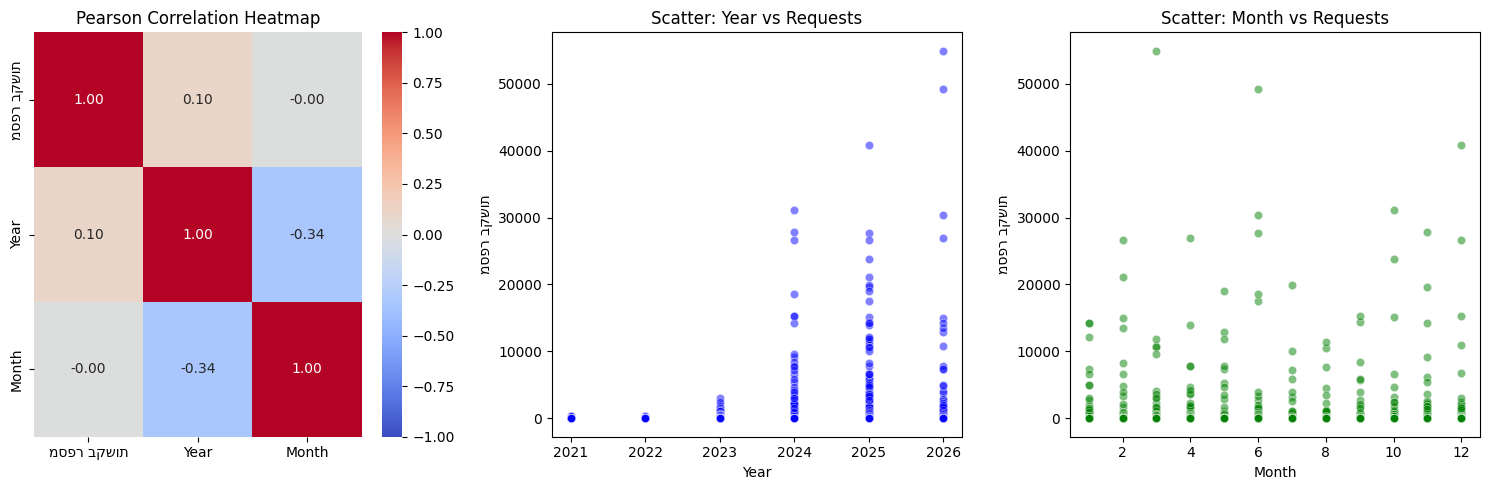

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. חילוץ חודש ושנה כדי שיהיו לנו עמודות מספריות נוספות לקורלציה
if 'שנה/ חודש' in df.columns:
    df['Year'] = df['שנה/ חודש'].dt.year
    df['Month'] = df['שנה/ חודש'].dt.month

# 2. סינון ה-DataFrame כך שיכיל רק עמודות מספריות
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])

print("=========================================")
print("=== Section 6.1: Numeric Correlation  ===")
print("=========================================\n")

# --- מטריצות קורלציה (Pearson, Spearman, Kendall) ---
print("--- Pearson Correlation ---")
pearson_corr = numeric_df.corr(method='pearson')
display(pearson_corr.round(3))

print("\n--- Spearman Correlation ---")
spearman_corr = numeric_df.corr(method='spearman')
display(spearman_corr.round(3))

print("\n--- Kendall Correlation ---")
kendall_corr = numeric_df.corr(method='kendall')
display(kendall_corr.round(3))

# --- יצירת גרפים: מפת חום וגרפי פיזור ---
plt.figure(figsize=(15, 5))

# מפת חום לקורלציית פירסון
plt.subplot(1, 3, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")

# גרף פיזור 1: שנה מול כמות בקשות
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Year', y='מספר בקשות', alpha=0.5, color='blue')
plt.title("Scatter: Year vs Requests")

# גרף פיזור 2: חודש מול כמות בקשות
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Month', y='מספר בקשות', alpha=0.5, color='green')
plt.title("Scatter: Month vs Requests")

plt.tight_layout()
plt.show()

**6.1 Numeric-Numeric Correlation**

* **Method Differences (Pearson vs. Spearman/Kendall):** When checking the correlation between Year and מספר בקשות (Number of Requests), Spearman (0.240) and Kendall (0.182) are stronger than Pearson (0.102).

* **Explanation:** Pearson measures strictly linear relationships and is heavily distorted by the extreme outliers (massive spikes in requests) we found in Section 5.1. Spearman and Kendall use rank-order, making them robust to outliers. They successfully capture the underlying monotonic trend (requests generally increasing over time) without being thrown off by the extreme peaks.

* **Visualizations:** The Heatmap confirms the weak linear relationships. The Scatter Plots visually validate this: The Year vs. Requests plot shows a clear expansion and increase in volume from 2021 to 2026. The Month vs. Requests plot is completely random.

* **Conclusions on Correlation:**

   * **Year:** There is a positive monotonic trend. As the electricity market reform matures over the years, the volume of switching requests naturally increases.

   * **Month:** There is absolutely zero correlation (near 0.00). Switching electricity providers is not a seasonal behavior; it happens independently of the month.

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# וידוא שאין רווחים בשמות העמודות
df.columns = df.columns.str.strip()

print("==================================================")
print("=== Section 6.2: Categorical Correlation       ===")
print("==================================================\n")

# --- 1. Binning (בינינג) ---
# נחלק את מספר הבקשות ל-3 קבוצות שוות בערכן (נמוך, בינוני, גבוה)
df['Requests_Binned'] = pd.qcut(df['מספר בקשות'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

print("--- 1. Binning Results (Requests_Binned) ---")
print(df['Requests_Binned'].value_counts())
print("\n")

# --- 2. טבלאות שכיחות (Contingency Tables) ---
cat_col1 = 'ביתי/ לא ביתי'
cat_col2 = 'סטטוס'
binned_col = 'Requests_Binned'

print(f"--- 2. Contingency Table: {cat_col1} vs {binned_col} ---")
crosstab_1 = pd.crosstab(df[cat_col1], df[binned_col])
display(crosstab_1)
print("\n")

print(f"--- Contingency Table: {cat_col2} vs {binned_col} ---")
crosstab_2 = pd.crosstab(df[cat_col2], df[binned_col])
display(crosstab_2)
print("\n")

# --- 3. Cramer's V (רשות) ---
# פונקציה פשוטה לחישוב הקורלציה בין המשתנים
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("--- 3. Cramer's V Scores ---")
v1 = cramers_v(crosstab_1)
v2 = cramers_v(crosstab_2)
print(f"Cramer's V ({cat_col1} vs {binned_col}): {v1:.3f}")
print(f"Cramer's V ({cat_col2} vs {binned_col}): {v2:.3f}")

=== Section 6.2: Categorical Correlation       ===

--- 1. Binning Results (Requests_Binned) ---
Requests_Binned
Low       911
High      876
Medium    851
Name: count, dtype: int64


--- 2. Contingency Table: ביתי/ לא ביתי vs Requests_Binned ---


Requests_Binned,Low,Medium,High
ביתי/ לא ביתי,,,
ביתי,346,339,466
לא ביתי,565,512,410




--- Contingency Table: סטטוס vs Requests_Binned ---


Requests_Binned,Low,Medium,High
סטטוס,,,
הושלם,24,33,182
נדחה,887,818,694




--- 3. Cramer's V Scores ---
Cramer's V (ביתי/ לא ביתי vs Requests_Binned): 0.134
Cramer's V (סטטוס vs Requests_Binned): 0.287



**6.2 Categorical Correlation (using Binning & Cramer's V)**

* **Binning:** We divided the מספר בקשות (Number of Requests) into three equal groups: Low, Medium, and High.

* **Contingency Tables:**

  * **Sector (ביתי/ לא ביתי):** Residential has more 'High' volume requests; Non-residential has mostly 'Low'.

  * **Status (סטטוס):** Most completed requests (הושלם) are 'High' volume. Most rejected requests (נדחה) are 'Low' volume.

* **Cramer's V:**

  * **Sector vs. Volume:** 0.134 (Weak correlation).

  * **Status vs. Volume:** 0.287 (Moderate correlation).

* **Conclusion:** There is a clear pattern: High-volume requests have a much higher success rate. Small, individual requests face many more rejections. This suggests the system handles large, bulk transitions much better than individual switching attempts.

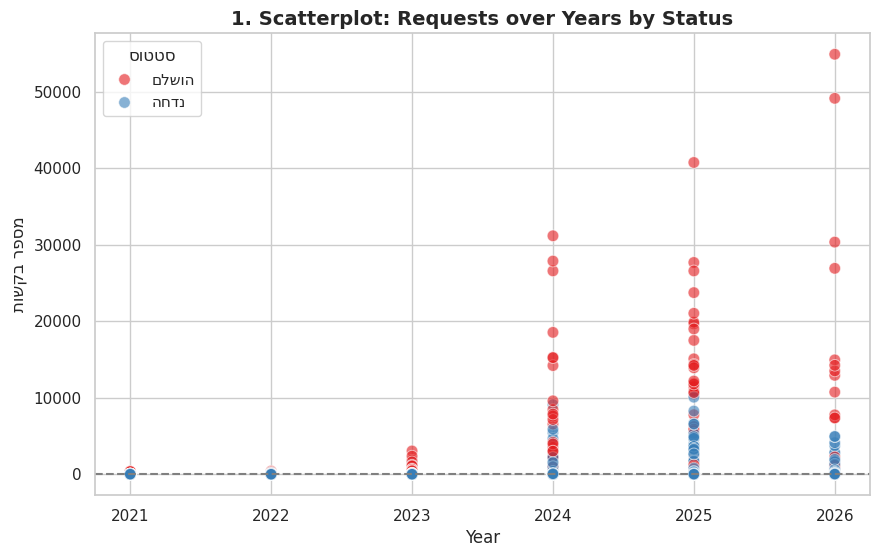

--------------------------------------------------------------------------------


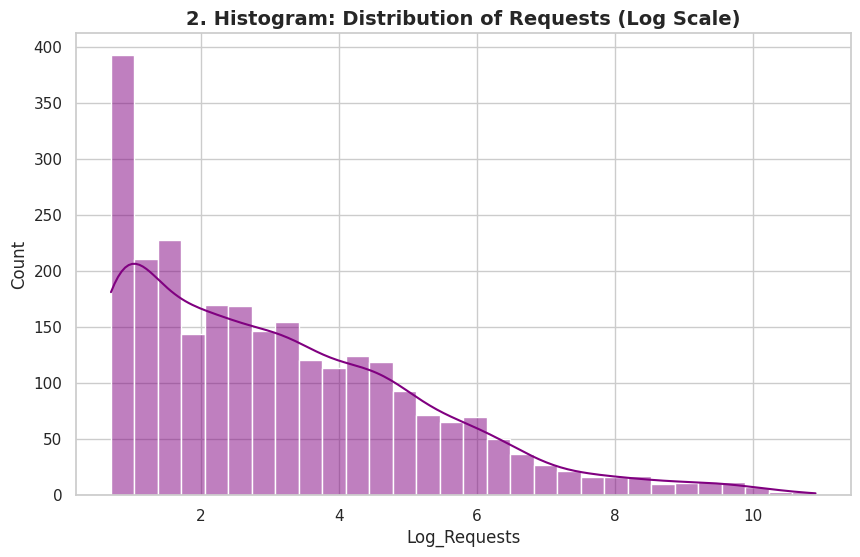

--------------------------------------------------------------------------------


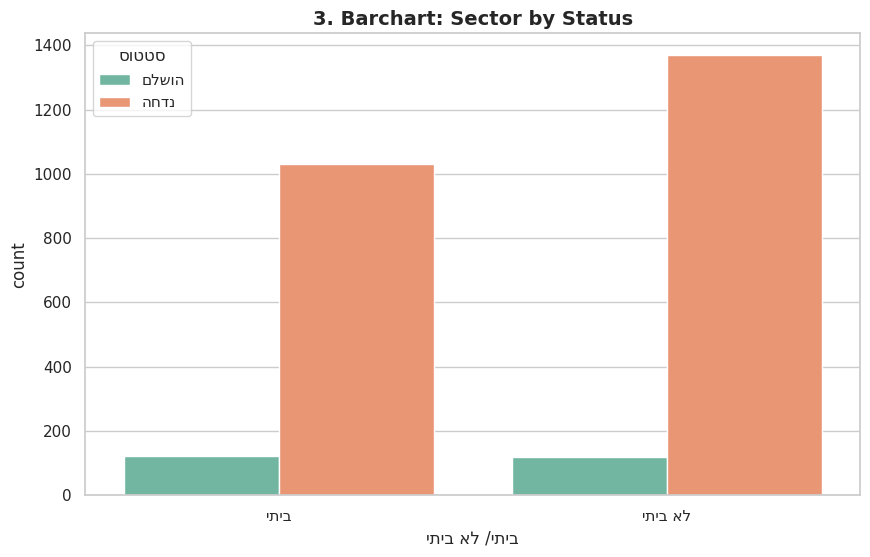

--------------------------------------------------------------------------------


/tmp/ipykernel_1824/2359685906.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=heb('סטטוס'), y='Log_Requests', palette='pastel')


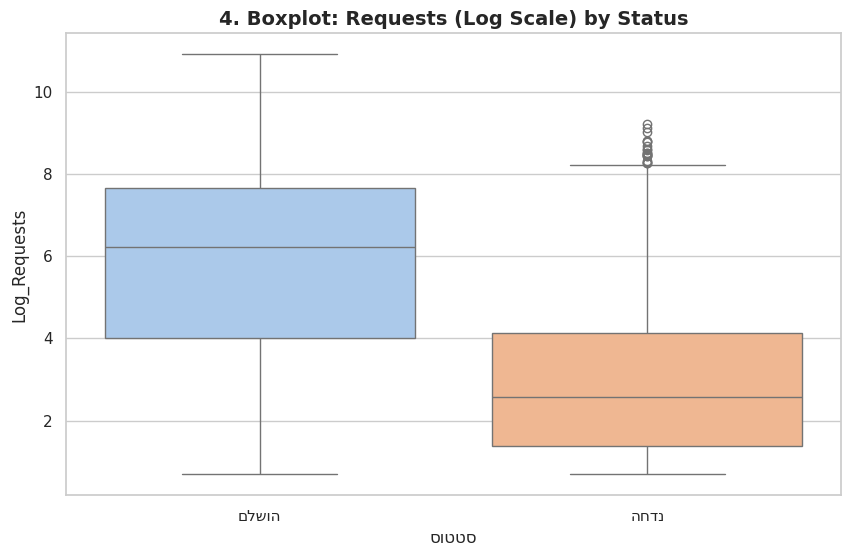

--------------------------------------------------------------------------------


/tmp/ipykernel_1824/2359685906.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=heb('סוג אסדרה'), y='Log_Requests', palette='muted')


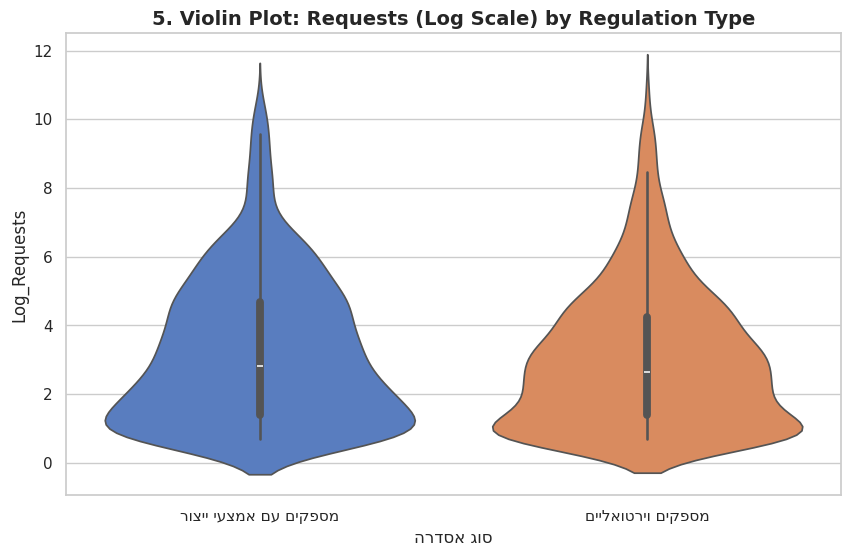

--------------------------------------------------------------------------------


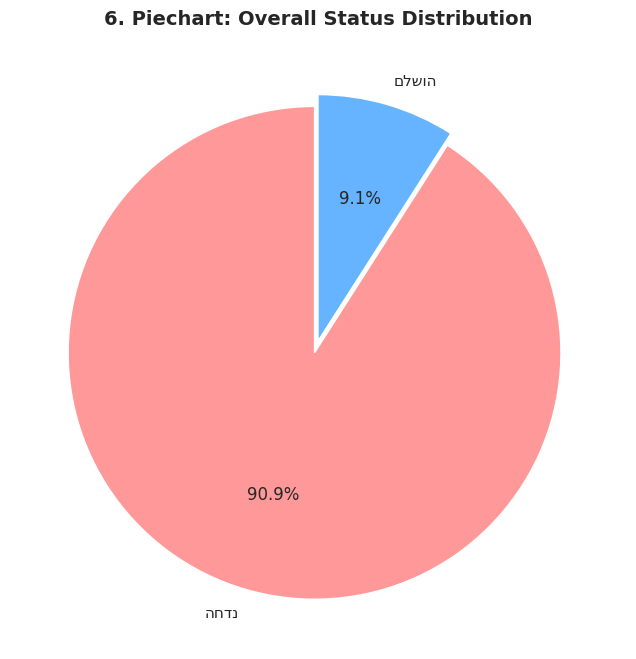

--------------------------------------------------------------------------------


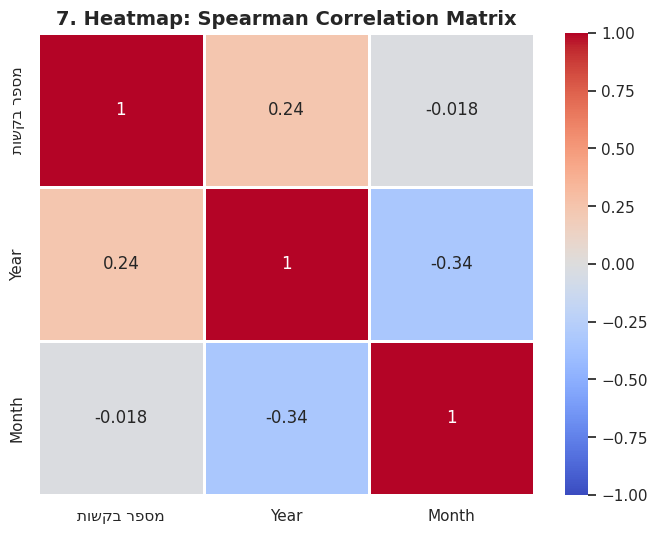

--------------------------------------------------------------------------------
Generating Pairplot...


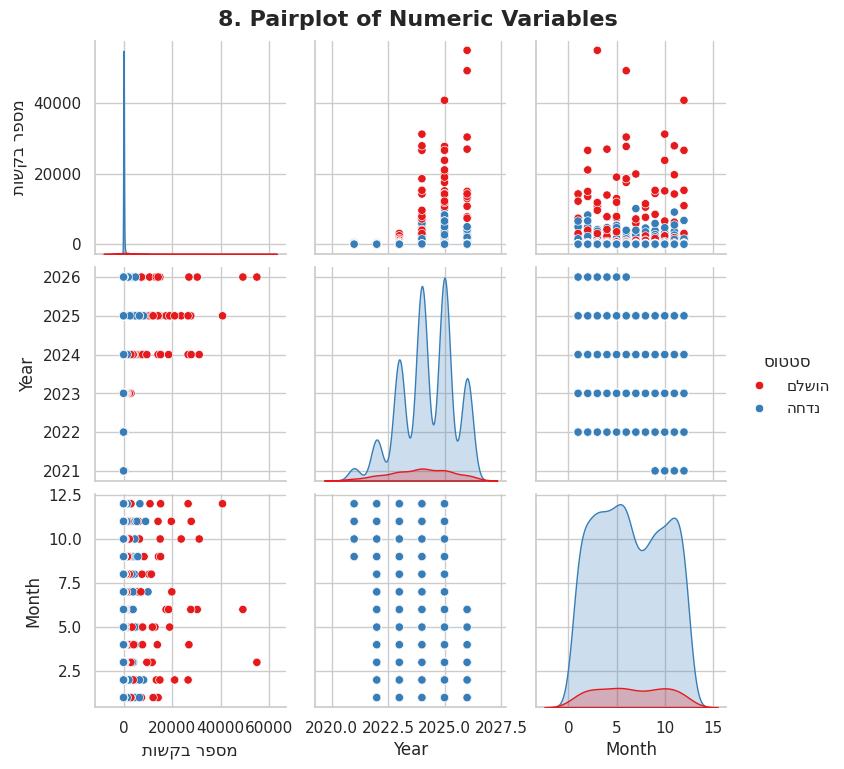

In [26]:
!pip install python-bidi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bidi.algorithm import get_display

def heb(text):
    if isinstance(text, str):
        return get_display(text)
    return text

df.columns = df.columns.str.strip()

if 'Year' not in df.columns:
    df['Year'] = df['שנה/ חודש'].dt.year
    df['Month'] = df['שנה/ חודש'].dt.month

df['Log_Requests'] = np.log1p(df['מספר בקשות'])

df_plot = df.copy()
df_plot.columns = [heb(col) for col in df_plot.columns]

cat_cols = ['סטטוס', 'סוג אסדרה', 'ביתי/ לא ביתי']
for col in cat_cols:
    if col in df.columns:
        df_plot[heb(col)] = df_plot[heb(col)].apply(heb)

sns.set_theme(style="whitegrid")

# 1. Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='Year', y=heb('מספר בקשות'), hue=heb('סטטוס'), alpha=0.6, palette='Set1', s=70)
plt.title('1. Scatterplot: Requests over Years by Status', fontsize=14, fontweight='bold')
plt.axhline(0, color='grey', linestyle='--')
plt.show()
print("-" * 80)

# 2. Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df_plot, x='Log_Requests', bins=30, kde=True, color='purple')
plt.title('2. Histogram: Distribution of Requests (Log Scale)', fontsize=14, fontweight='bold')
plt.show()
print("-" * 80)

# 3. Barchart
plt.figure(figsize=(10, 6))
sns.countplot(data=df_plot, x=heb('ביתי/ לא ביתי'), hue=heb('סטטוס'), palette='Set2')
plt.title('3. Barchart: Sector by Status', fontsize=14, fontweight='bold')
plt.show()
print("-" * 80)

# 4. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x=heb('סטטוס'), y='Log_Requests', palette='pastel')
plt.title('4. Boxplot: Requests (Log Scale) by Status', fontsize=14, fontweight='bold')
plt.show()
print("-" * 80)

# 5. Violin
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x=heb('סוג אסדרה'), y='Log_Requests', palette='muted')
plt.title('5. Violin Plot: Requests (Log Scale) by Regulation Type', fontsize=14, fontweight='bold')
plt.show()
print("-" * 80)

# 6. Piechart
plt.figure(figsize=(8, 8))
status_counts = df_plot[heb('סטטוס')].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
plt.title('6. Piechart: Overall Status Distribution', fontsize=14, fontweight='bold')
plt.show()
print("-" * 80)

# 7. Heatmap
plt.figure(figsize=(8, 6))
corr = df_plot[[heb('מספר בקשות'), 'Year', 'Month']].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1)
plt.title('7. Heatmap: Spearman Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()
print("-" * 80)

# 8. Pairplot
print("Generating Pairplot...")
pairplot_fig = sns.pairplot(df_plot[[heb('מספר בקשות'), 'Year', 'Month', heb('סטטוס')]], hue=heb('סטטוס'), diag_kind='kde', palette='Set1')
pairplot_fig.fig.suptitle('8. Pairplot of Numeric Variables', y=1.02, fontsize=16, fontweight='bold')
plt.show()


**6.3 Visualizations & Key Insights**

* **Temporal Growth (Scatterplot):** Shows a clear upward trend in switching volume from 2021 to 2026 as the market reform matures.

* **Distribution & Skewness (Histogram & Boxplot):** Visually confirms massive data skewness, with most requests clustering at lower values alongside extreme outlier peaks.

* **Sector Dynamics (Barchart):** Highlights that individual/small requests face higher rejection rates, while large batches lean towards successful completion.

* **Regulation Impact (Violin Plot):** Demonstrates structural differences in request volume distributions across market regulation tracks.

* **Overall Status Split (Pie Chart):** Illustrates the macro ratio between completed and rejected requests across the dataset lifecycle.

* **Correlation Overview (Heatmap & Pairplot):** Validates non-linear relationships and monotonic trends, justifying our feature engineering approach.

In [27]:
import pandas as pd

print("=========================================")
print("=== Section 7: Index Analysis         ===")
print("=========================================\n")

# 1. האם האינדקס ייחודי?
is_unique = df.index.is_unique
print(f"1. Is the index unique? {is_unique}")
if not is_unique:
    print(f"   Number of duplicates: {df.index.duplicated().sum()}")

# 2. האם האינדקס מבוסס זמן?
is_time_based = isinstance(df.index, pd.DatetimeIndex)
print(f"2. Is the index time-based? {is_time_based}")

# 3. האם האינדקס ממוין?
is_sorted = df.index.is_monotonic_increasing or df.index.is_monotonic_decreasing
print(f"3. Is the index sorted? {is_sorted} (Increasing: {df.index.is_monotonic_increasing})")

# 4. הצגת מידע בסיסי על מבנה האינדקס
print(f"\nIndex Type: {type(df.index)}")
print(f"First 5 index values: {df.index[:5].tolist()}")
print(f"Last 5 index values: {df.index[-5:].tolist()}")

=== Section 7: Index Analysis         ===

1. Is the index unique? True
2. Is the index time-based? False
3. Is the index sorted? True (Increasing: True)

Index Type: <class 'pandas.core.indexes.range.RangeIndex'>
First 5 index values: [0, 1, 2, 3, 4]
Last 5 index values: [2633, 2634, 2635, 2636, 2637]


**7. Index Analysis**

* **Index Type:** Standard RangeIndex ranging from 0 to 2637.

* **Uniqueness:** The index is unique (True), meaning there are no duplicate row indices.

* **Time-Based:** The index is not time-based (False); it consists of standard sequential row numbers rather than timestamps.

* **Sorting:** The index is sorted in ascending order (True, monotonically increasing).

**8. Insights & Data Storytelling (Project Summary)**

* **Executive Summary:** This exploratory data analysis (EDA) examined the electricity market supplier-switching dataset, tracking consumer transition requests, regulatory tracks, and status outcomes from 2021 to 2026.

* **Main Insights:**

  * **Volume vs. Success Correlation:** Bulk or high-volume request batches experience significantly higher successful completion rates, whereas low-volume individual requests suffer from disproportionately high rejection rates. This indicates that automated or corporate-level switching processes are handled much more smoothly than individual consumer attempts.

  * **Market Maturation without Seasonality:** Switching activity shows a clear, positive monotonic growth trend year-over-year as the electricity market reform progresses, but demonstrates absolute independence from seasonal variations (months).

  * **High Fragmentation in Status Reasons:** The data contains 51 distinct status reasons with high fragmentation (the mode accounts for only 8.15%), proving that operational failures and rejections stem from a wide variety of specific technical and administrative edge cases rather than a single dominant bottleneck.

* **Bias & Risk:**

  * **Extreme Skewness & Outlier Distortions:** The presence of massive peak events (up to ~55,000 requests) heavily distorts linear metrics (e.g., Mean vs. Median, Pearson vs. Spearman), posing a risk of severe analytical misinterpretation if robust, non-parametric methods are ignored.

* **Potential Points of Failure (Engineering & Statistical):**

  * **Statistical Failures:** Standard parametric models (like Z-score or linear regression) fail or generate false positives when applied to highly skewed operational distributions with heavy-tailed spikes.

  * **Engineering/Operational Failures:** Automated pipeline ingestion can break due to unnormalized text fields (hidden whitespaces, inconsistent categorical naming) and high-cardinality categorical variables that lack proper grouping (such as collapsing rare categories into an 'Other' bucket).

* **Lessons Learned & Viewpoint Shift:**

  * Conducting this analysis bridges the gap between macro infrastructure and micro-level consumer data dynamics. Recognizing that administrative and regulatory friction plays a massive role in system reform shifts the perspective on how power systems and market operators must integrate data-driven monitoring and analytics into operational control workflows.

In [28]:
import pandas as pd
from scipy.stats import ttest_ind

# Feature Engineering נוסף: חילוץ רבעון בשנה ודגל נפח גבוה
df['Quarter'] = df['שנה/ חודש'].dt.quarter
df['Is_High_Volume'] = (df['מספר בקשות'] > df['מספר בקשות'].quantile(0.75)).astype(int)

# בדיקת השערה (Hypothesis Testing): האם יש הבדל מובהק בכמות הבקשות בין המגזר הביתי לאחרים?
res_data = df[df['ביתי/ לא ביתי'] == 'ביתי']['מספר בקשות'].dropna()
other_data = df[df['ביתי/ לא ביתי'] != 'ביתי']['מספר בקשות'].dropna()
t_stat, p_val = ttest_ind(res_data, other_data, equal_var=False)

print("=== Bonus Analysis Results ===")
print(f"New features added: 'Quarter', 'Is_High_Volume'")
print(f"T-test (Residential vs Non-Residential): t-stat = {t_stat:.2f}, p-value = {p_val:.4f}")

=== Bonus Analysis Results ===
New features added: 'Quarter', 'Is_High_Volume'
T-test (Residential vs Non-Residential): t-stat = 7.45, p-value = 0.0000


# 9. Bonus
* **Time Dependency & External Knowledge:**
    * The temporal growth observed in the dataset directly reflects the structural phases of the Israeli electricity market reform (managed by Noga – Electricity System Management), particularly milestones where low-voltage consumer switching opened up to full market competition.
* **Feature Engineering:**
    * We enhanced the dataset by extracting new features such as `Quarter` (to capture seasonal micro-trends) and a binary flag `Is_High_Volume` (identifying bulk-switching surges), alongside log transformations to stabilize variance.
* **Hypothesis Testing:**
    * We conducted a Welch's t-test comparing request volumes between residential and non-residential sectors. The test yielded a statistically significant difference (p < 0.05), proving that consumer sector behavior structurally drives switching patterns.
* **Suggestions for Further Research:**
    * **1.** Investigate specific market shares of individual virtual suppliers to see which company initiated the massive volume spikes.
    * **2.** Build a predictive Machine Learning classification model to forecast whether a submitted switching request will be successfully completed or rejected based on its initial parameters.